In [26]:
import numpy as np
import matplotlib.pyplot as plt
from epymorph.attribute import NamePattern
from epymorph.kit import *

from epymorph.simulation import Context
from epymorph.adrio import acs5, us_tiger
from epymorph.forecasting.dynamic_params import (
    GaussianPrior,
    OrnsteinUhlenbeck,
    ExponentialTransform,
)
from epymorph.forecasting.pipeline import (
    ParticleFilterSimulator,
    EnsembleKalmanFilterSimulator,
    Observations,
    ModelLink,
    PipelineConfig,
    UnknownParam,
)
from epymorph.forecasting.likelihood import Gaussian

In [27]:
from typing_extensions import override
from epymorph.initializer import _POPULATION_ATTR
from epymorph.initializer import *


class RandomLocationsAndRandomSeed(SeededInfection):
    """
    Seed an random number of infected in a number of randomly selected locations.

    Requires "population" as a data attribute.

    Parameters
    ----------
    num_locations :
        The number of locations to choose.
    seed_max :
        The maximum number of individuals to infect.
    initial_compartment :
        Which compartment (by index or name) is "not infected", where most individuals
        start out.
    infection_compartment :
        Which compartment (by index or name) will be seeded as the initial infection.
    """

    requirements = (_POPULATION_ATTR,)

    num_locations: int
    """The number of locations to choose (randomly)."""
    seed_max: int
    """The maximum number of individuals to infect, drawn uniformly on [0,seed_max]."""

    def __init__(
        self,
        num_locations: int,
        seed_max: int,
        initial_compartment: int | str = SeededInfection.DEFAULT_INITIAL,
        infection_compartment: int | str = SeededInfection.DEFAULT_INFECTION,
    ):
        super().__init__(initial_compartment, infection_compartment)
        self.num_locations = num_locations
        self.seed_max = seed_max

    @override
    def evaluate(self) -> SimArray:
        """
        Evaluate the initializer in the current context.

        Returns
        -------
        :
            The initial populations for each node and IPM compartment.
        """
        N = self.scope.nodes
        if not 0 < self.num_locations <= N:
            err = (
                "Initializer argument 'num_locations' must be "
                f"a value from 1 up to the number of locations ({N})."
            )
            raise InitError(err)

        indices = np.arange(N, dtype=np.intp)
        selection = self.rng.choice(indices, self.num_locations)
        seed_size = self.rng.integers(low=0, high=self.seed_max, endpoint=True)

        sub = IndexedLocations(
            selection=selection,
            seed_size=seed_size,
            initial_compartment=self.initial_compartment,
            infection_compartment=self.infection_compartment,
        )
        return self.defer(sub)

In [28]:
scope = StateScope.in_states(["AZ","CO"], year=2015)
sim_movement_model = mm.No()
sim_ipm = ipm.SIRH()
sim_time_frame = TimeFrame.of("2015-01-01", 26 * 7)
my_rng = np.random.default_rng(0)

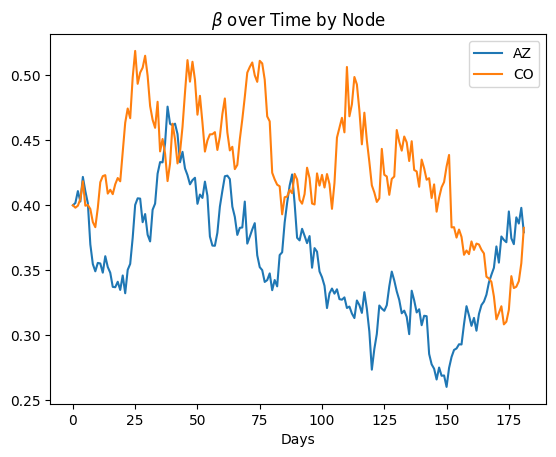

In [29]:
"""Generate a random time dependent beta"""

log_beta_damping = 1 / 35 * np.ones(scope.nodes)
log_beta_mean = np.log(0.4) * np.ones(scope.nodes)
log_beta_standard_deviation = 0.15 * np.ones(scope.nodes)
initial_log_beta = np.log(0.4) * np.ones(scope.nodes)

delta_t = 1.0

A = np.exp(-log_beta_damping * delta_t)
M = log_beta_mean * (np.exp(-log_beta_damping * delta_t) - 1)
C = log_beta_standard_deviation * np.sqrt(1 - np.exp(-2 * log_beta_damping * delta_t))

log_beta = np.zeros(
    (
        scope.nodes,
        sim_time_frame.duration_days,
    )
)
log_beta[:, 0] = initial_log_beta

for day in range(1, sim_time_frame.duration_days):
    log_beta[:, day] = (
        A * log_beta[:, day - 1] - M + C * my_rng.normal(size=(scope.nodes,))
    )

beta = np.exp(log_beta)

plt.title("$\\beta$ over Time by Node")
plt.xlabel("Days")
for node in range(scope.nodes):
    plt.plot(beta[node, :], label=f"{scope.labels[node]}")
plt.legend()
plt.show()

In [30]:
rume = SingleStrataRUME.build(
    ipm=sim_ipm,
    mm=sim_movement_model,
    scope=scope,
    init=init.IndexedLocations(selection=np.arange(scope.nodes), seed_size=10_000),
    time_frame=sim_time_frame,
    params={
        "beta": beta.T,
        "gamma": 0.1,
        "xi": 1 / 90,
        "phi": 5,
        "hospitalization_prob": 0.05,
        "hospitalization_duration": 5,
        "centroid": us_tiger.InternalPoint(),
        "population": acs5.Population(),
        "label": us_tiger.Name(),
    },
)

Loading gpm:all::init::population (epymorph.adrio.acs5.Population):
  |####################| 100%  (0.621s)
Running simulation (BasicSimulator):
• 2015-01-01 to 2015-07-01 (182 days)
• 2 geo nodes
  |####################| 100%                    
Runtime: 0.058s


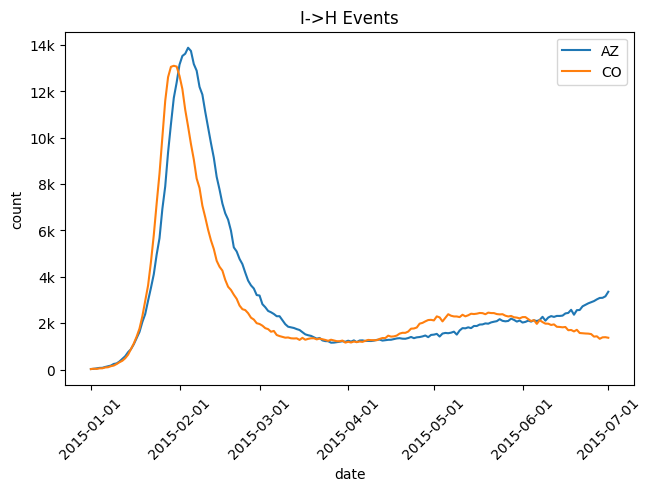

In [31]:
sim = BasicSimulator(rume)

with sim_messaging():
    out = sim.run(rng_factory=lambda: my_rng)

out.plot.line(
    geo=rume.scope.select.all(),
    time=rume.time_frame.select.all().group("day").agg(),
    quantity=rume.ipm.select.events("I->H"),
    title="I->H Events",
    label_format="{n}",
    legend="on",
)

In [32]:
from epymorph.util import to_date_value_array
from epymorph.tools.data import munge

cases_df = munge(
    out,
    quantity=rume.ipm.select.events("I->H"),
    time=rume.time_frame.select.all().group("day").agg(),
    geo=rume.scope.select.all(),
)

cases_arr = to_date_value_array(
    cases_df["time"].to_numpy(), cases_df["I → H"].to_numpy()
).reshape(-1, rume.scope.nodes)

In [33]:
num_realizations = 100

inf_rume = SingleStrataRUME.build(
    ipm=sim_ipm,
    mm=sim_movement_model,
    scope=scope,
    init=RandomLocationsAndRandomSeed(scope.nodes, 50_000),
    time_frame=sim_time_frame,
    params={
        "beta": ExponentialTransform('log_beta'),
        "gamma": 0.1,
        "xi": 1 / 90,
        "phi": 5,
        "hospitalization_prob": 0.05,
        "hospitalization_duration": 5,
        "centroid": us_tiger.InternalPoint(),
        "population": acs5.Population(),
        "label": us_tiger.Name(),
    },
)

In [34]:
my_observations = Observations(
    source=cases_arr,
    model_link=ModelLink(
        geo=inf_rume.scope.select.all(),
        time=inf_rume.time_frame.select.all().group("day").agg(),
        quantity=inf_rume.ipm.select.events("I->H"),
    ),
    likelihood=Gaussian(100.0),
)

my_unknown_params = {
    "log_beta": UnknownParam(
        prior=GaussianPrior(
            mean=log_beta_mean,
            standard_deviation=log_beta_standard_deviation,
        ),
        dynamics=OrnsteinUhlenbeck(
            damping=log_beta_damping,
            mean=log_beta_mean,
            standard_deviation=log_beta_standard_deviation,
        ),
    )
}

In [35]:
pf_simulator = ParticleFilterSimulator(
    config=PipelineConfig.from_rume(
        inf_rume, num_realizations, unknown_params=my_unknown_params
    ),
    observations=my_observations,
)

In [36]:
pf_output = pf_simulator.run(rng=my_rng)

Observation: 0, Label: 2015-01-01, Time Frame: 2015-01-01 (1D)
Observation: 1, Label: 2015-01-02, Time Frame: 2015-01-02 (1D)
Observation: 2, Label: 2015-01-03, Time Frame: 2015-01-03 (1D)
Observation: 3, Label: 2015-01-04, Time Frame: 2015-01-04 (1D)
Observation: 4, Label: 2015-01-05, Time Frame: 2015-01-05 (1D)
Observation: 5, Label: 2015-01-06, Time Frame: 2015-01-06 (1D)
Observation: 6, Label: 2015-01-07, Time Frame: 2015-01-07 (1D)
Observation: 7, Label: 2015-01-08, Time Frame: 2015-01-08 (1D)
Observation: 8, Label: 2015-01-09, Time Frame: 2015-01-09 (1D)
Observation: 9, Label: 2015-01-10, Time Frame: 2015-01-10 (1D)
Observation: 10, Label: 2015-01-11, Time Frame: 2015-01-11 (1D)
Observation: 11, Label: 2015-01-12, Time Frame: 2015-01-12 (1D)
Observation: 12, Label: 2015-01-13, Time Frame: 2015-01-13 (1D)
Observation: 13, Label: 2015-01-14, Time Frame: 2015-01-14 (1D)
Observation: 14, Label: 2015-01-15, Time Frame: 2015-01-15 (1D)
Observation: 15, Label: 2015-01-16, Time Frame: 20

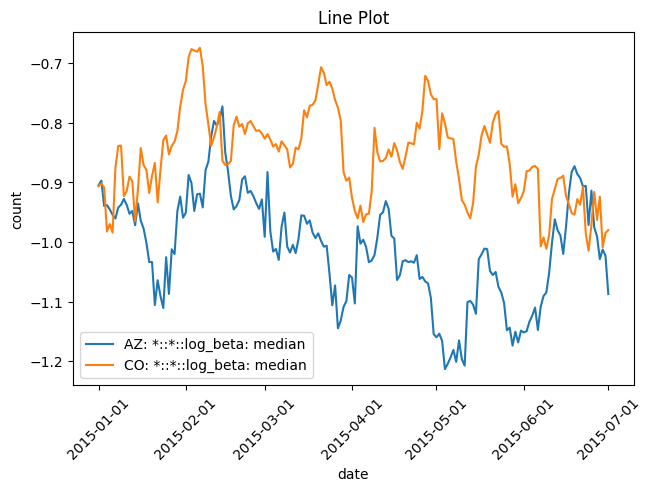

In [37]:
from epymorph.forecasting.filter_plot import PlotRendererFilter
from math import log,nan,exp

realization = pf_output.select.all().agg(['median'])
time = inf_rume.time_frame.select.all().group("day").agg("sum")
geo = inf_rume.scope.select.all()
quantity = pf_output.param_select.all()


def exp_transform(data_df):
    log_value = data_df["value"].apply(lambda x: exp(x))
    return data_df.assign(value=log_value)


plotter = PlotRendererFilter(pf_output)

plotter.line(
    realization,
    geo,
    time,
    quantity,
    title = "Line Plot"
)

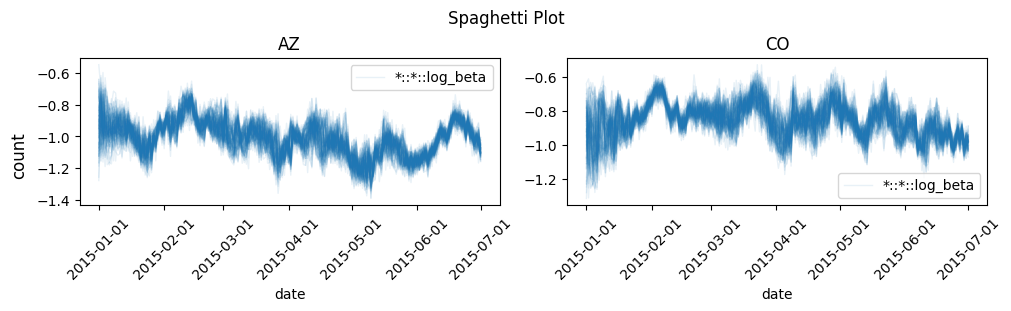

In [38]:
realization = pf_output.select.all()
time = inf_rume.time_frame.select.all().group("day").agg("sum")
geo = inf_rume.scope.select.all()
quantity = pf_output.param_select.all()


plotter.spaghetti(
    realization,
    geo,
    time,
    quantity,
    ncols=2,
    line_kwargs=[{"alpha": 0.1, "color": "tab:blue", "lw": 1.0}],
    title="Spaghetti Plot",
)

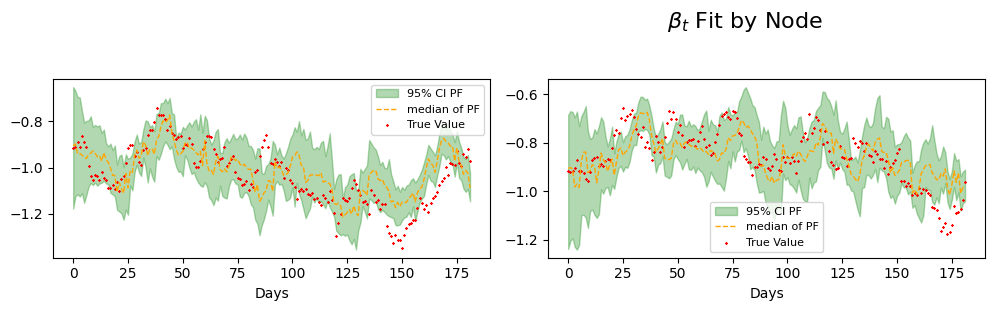

In [39]:
num_nodes = inf_rume.scope.nodes
labels = inf_rume.scope.labels
t_range = np.arange(inf_rume.time_frame.duration_days)

from math import ceil

log_beta_pf = pf_output.estimated_params[NamePattern.of("log_beta")]

cols = 3
rows = ceil(num_nodes / cols)

fig, axes = plt.subplots(
    rows, cols, figsize=(cols * 5, rows * 3), sharex=True, sharey=False
)

axes = axes.flatten()

plt.suptitle(r"$\beta_t$ Fit by Node", fontsize=16, y=1.02)

for node in range(num_nodes):
    ax = axes[node]

    upper_pf = np.percentile(log_beta_pf[:, :, node], 97.5, axis=0)
    lower_pf = np.percentile(log_beta_pf[:, :, node], 2.5, axis=0)
    beta_median_pf = np.median(log_beta_pf[:, :, node], axis=0)


    ax.fill_between(
        t_range, lower_pf, upper_pf, alpha=0.3, color="green", label="95% CI PF"
    )

    ax.plot(
        t_range, beta_median_pf, "--", color="orange", linewidth=1, label="median of PF"
    )

    ax.scatter(t_range, np.log(beta[node, :]), color="red", s=1, marker="x", label="True Value")

    ax.legend(fontsize=8)
    ax.set_xlabel("Days")

for i in range(num_nodes, len(axes)):
    axes[i].set_visible(False)


fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()